In [ ]:
# need to do first:
# normalize columns: total demand, mode score, region location (1-10) V
# don't forget, total demand - use log, then filter 0 and then normalize 1-10
# weight pop and emp columns, then normalize (1-10)
# weight bus terminal column, then normalize (1-10)

# all normalizations should be within the hub type group

In [ ]:
import pandas as pd
import numpy as np

import os

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Hubs/grouped_hubs_ready_for_scoring_29102025.csv', encoding='utf-8')

In [ ]:
df.head(1)

,Unnamed: 0,group,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,...,emp_1000_1500,id,term_type,Region_category,Location_category,RegionLocation,Num_Modes,score,bus_terminal,HubType
0,0,0,"POLYGON ((35.58265301880704 33.2100839260914, ...",['8a2da4100a27fff'],[31655],['Interurban Rail'],National,"['rail_1_1', 'rail_1_2']","מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית...",צפון,...,5330.187199,928.0,חניון לילה,1,1,1,1,14.0,1,Train Station


In [ ]:
df.drop(columns='Unnamed: 0', inplace=True)
df.set_index('group', inplace=True)

In [ ]:
df.head(1)

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,emp_1000_1500,id,term_type,Region_category,Location_category,RegionLocation,Num_Modes,score,bus_terminal,HubType
group,,,,,,,,,,,,,,,,,,,,,
0,"POLYGON ((35.58265301880704 33.2100839260914, ...",['8a2da4100a27fff'],[31655],['Interurban Rail'],National,"['rail_1_1', 'rail_1_2']","מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית...",צפון,צפון,3037.685341,...,5330.187199,928.0,חניון לילה,1,1,1,1,14.0,1,Train Station


In [ ]:
for i, row in df.iterrows():
  if '400380' in row['node']:
    print(i)

267


# Filter out groups with less than 1000 total demand

In [ ]:
df = df[df['TotalDemand']>=1000]

In [ ]:
def make_list(txt):
  txt = txt.replace('[','').replace(']','').replace("'","").split(',')
  return txt

In [ ]:
df['Mode_Planned'] = df['Mode_Planned'].apply(lambda x: make_list(x))

In [ ]:
df = df[df['Mode_Planned'].apply(lambda x: len(x) > 1)]

In [ ]:
df

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,emp_1000_1500,id,term_type,Region_category,Location_category,RegionLocation,Num_Modes,score,bus_terminal,HubType
group,,,,,,,,,,,,,,,,,,,,,
8,"POLYGON ((35.29482835672485 32.92382726524076,...","['8a2da4c3119ffff', '8a2da4c3119ffff']","[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_5_1', 'rail_5_2', 'rail_1_1', 'rail_1_2...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,5997.050771,NaN,NaN,1,1,1,2,44.0,0,Regional
16,"POLYGON ((35.09908985427145 33.00363199489554,...","['8a2da4cb27a7fff', '8a2da4cb27a7fff']","[31624, 31624]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_2_1', 'rail_2_2,', 'rail_3_1', 'rail_3_2']","גדוד 21, קרית בן-גוריון, נהריה, נפת עכו, מחוז ...",חיפה,טבעת,24623.819497,...,7279.293252,421.0,מסוף בינוני,1,2,2,2,33.0,2,Regional
33,"POLYGON ((35.29795846044803 32.69299932246631,...","['8a2da4d3468ffff', '8a2da4d346c7fff', '8a2da4...","[36987, 34034, 35023, 36964, 36965]","[BRT, LRT]",Haifa,"['brt031', 'brt032,', 'brt032', 'brt042,', 'lr...","توفيق زياد/شارع 75, 75, ארמון האגמון, الناصرة,...",צפון,צפון,4996.270629,...,11198.039099,NaN,NaN,1,1,1,2,52.8,0,Local
58,MULTIPOLYGON (((35.08953129526264 32.858452695...,"['8a2da4d92c87fff', '8a3f4db34b2ffff']","[34051, 1006]","[LRT, BRT]",Haifa,"['lrt07,', 'R321-1', 'R1001-2', 'R322-1', 'R10...","שדרות ירושלים, משכנות האמנים, קריית מוצקין, נפ...",חיפה,טבעת,15316.333161,...,11650.623456,1354.0,מתקן משולב,1,2,2,2,44.0,3,Local
59,POLYGON ((35.131894689624644 32.82304690505347...,"['8a2da4d94b17fff', '8a2da4d94b17fff', '8a2da4...","[1000, 1000, 34014, 34014, 36850, 36850]","[BRT, LRT]",Haifa,"['brt012,', 'R1002-2', 'R1002-1,', 'lrt01', 'l...","79, מועצה אזורית זבולון, נפת חיפה, מחוז חיפה, ...",חיפה,טבעת,9587.610309,...,3747.472034,10782.0,מסוף בינוני,1,2,2,2,72.6,2,Local
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,POLYGON ((34.876904245572504 31.94688757532439...,"['8a3f4ddaaa37fff', '8a3f4ddaaa37fff']","[400320, 400320]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_3_1', 'rail_3_2', 'rail_4_1', 'rail_4_2...","לוד, יוספטל, הרכבת, שניר, לוד, נפת רמלה, מחוז ...",תל אביב,טבעת,45254.790000,...,16090.528340,896.0,מסוף קטן,0,2,0,2,99.0,2,Regional
983,MULTIPOLYGON (((34.878416394190026 31.92704293...,"['8a3f4ddaad37fff', '8a3f4ddaadaffff', '8a3f4d...","[515045, 400410, 400410, 521045, 521045]","[BRT, Rail, Rail, LRT, Interurban Rail, S...",Tel,"['rail_3_1', 'rail_3_2', 'rail_4_1', 'rail_4_2...","רמלה, נפת רמלה, מחוז המרכז, 7135275, ישראל",תל אביב,טבעת,58482.360000,...,10673.906131,133.0,מסוף בינוני,0,2,0,4,101.4,2,National
984,MULTIPOLYGON (((34.87859074857701 31.966870753...,"['8a3f4ddab827fff', '8a3f4ddab827fff', '8a3f4d...","[400310, 521080, 170132]","[Rail, BRT, Interurban Rail]",National,"['rail_5_1', 'rail_5_2,', 'Yelw-N,', 'BRT1-1']","שניר, לוד, נפת רמלה, מחוז המרכז, 7147308, ישראל",תל אביב,טבעת,13379.260000,...,12179.587914,897.0,מתקן משולב,0,2,0,2,22.0,3,Regional


In [ ]:
df.columns

Index(['geometry', 'h3_index', 'node', 'Mode_Planned', 'Model', 'Line_Unique',
       'address', 'area', 'location', 'TotalDemand', 'TotalTransfers',
       'Total_Unique_Lines', 'BRT Lines', 'Cable Line Lines',
       'Funicular Lines', 'HighSpeed Rail Lines', 'Interurban Rail Lines',
       'LRT Lines', 'Metro Lines', 'Suburban Rail Lines', 'centroid',
       'pop_0_500', 'emp_0_500', 'pop_500_1000', 'emp_500_1000',
       'pop_1000_1500', 'emp_1000_1500', 'id', 'term_type', 'Region_category',
       'Location_category', 'RegionLocation', 'Num_Modes', 'score',
       'bus_terminal', 'HubType'],
      dtype='object')

### Normalize Region Location and Mode score

In [ ]:
def norm_col(df, col) -> pd.DataFrame:
  min_val = df[col].min()
  max_val = df[col].max()

  df[col + '_Norm'] = 1 + (df[col] - min_val) * (10 - 1) / (max_val - min_val)

  return df

In [ ]:
cols_to_normalize = ['RegionLocation', 'score','bus_terminal']

In [ ]:
for hub in df['HubType'].unique():
  for col in cols_to_normalize:
    df.loc[df['HubType'] == hub, col + '_Norm'] = norm_col(df[df['HubType'] == hub].copy(), col)[col + '_Norm']

In [ ]:
df['score_Norm'].max()

10.0

In [ ]:
df[['score','score_Norm']].loc[777,:]

KeyError: 777

## Normalize total deman

In [ ]:
def norm_demand(df, col) -> pd.DataFrame:
  # calculate LogTotalDemand_Daily and assign to a new column
  df['Log' + col] = df[col].apply(lambda x: 0 if x == 0 else np.log(x))

  # filter out rows where 'Log' + col is greater than 0
  filtered_df = df[df['Log' + col] > 0]

  # if filtered_df is empty assign min and max to 0 to avoid errors and return df with added columns.
  if filtered_df.empty:
    df['Log' + col + '_Norm'] = 0
    return df

  # calculate min and max from the 'Log' + col column of the filtered dataframe
  min_val = filtered_df['Log' + col].min()
  max_val = filtered_df['Log' + col].max()

  # calculate and assign LogTotalDemand_Daily_Norm values
  df['Log' + col + '_Norm'] = 1 + (df['Log' + col] - min_val) * (10 - 1) / (max_val - min_val)

  return df

In [ ]:
col = 'TotalDemand'
for hub in df['HubType'].unique():
  # df.loc[df['HubType'] == hub, col + '_Norm'] = norm_col(df[df['HubType'] == hub].copy(), col)[col + '_Norm']
  df.loc[df['HubType'] == hub, col + '_Norm'] = norm_demand(df[df['HubType'] == hub].copy(), col)['Log' + col + '_Norm']

In [ ]:
df.columns

Index(['geometry', 'h3_index', 'node', 'Mode_Planned', 'Model', 'Line_Unique',
       'address', 'area', 'location', 'TotalDemand', 'TotalTransfers',
       'Total_Unique_Lines', 'BRT Lines', 'Cable Line Lines',
       'Funicular Lines', 'HighSpeed Rail Lines', 'Interurban Rail Lines',
       'LRT Lines', 'Metro Lines', 'Suburban Rail Lines', 'centroid',
       'pop_0_500', 'emp_0_500', 'pop_500_1000', 'emp_500_1000',
       'pop_1000_1500', 'emp_1000_1500', 'id', 'term_type', 'Region_category',
       'Location_category', 'RegionLocation', 'Num_Modes', 'score',
       'bus_terminal', 'HubType', 'RegionLocation_Norm', 'score_Norm',
       'bus_terminal_Norm', 'TotalDemand_Norm'],
      dtype='object')

In [ ]:
for hub in df['HubType'].unique():
  print(df[df['HubType']==hub]['TotalDemand_Norm'].min())

1.0
1.0
1.0
1.0


In [ ]:
df.columns

Index(['geometry', 'h3_index', 'node', 'Mode_Planned', 'Model', 'Line_Unique',
       'address', 'area', 'location', 'TotalDemand', 'TotalTransfers',
       'Total_Unique_Lines', 'BRT Lines', 'Cable Line Lines',
       'Funicular Lines', 'HighSpeed Rail Lines', 'Interurban Rail Lines',
       'LRT Lines', 'Metro Lines', 'Suburban Rail Lines', 'centroid',
       'pop_0_500', 'emp_0_500', 'pop_500_1000', 'emp_500_1000',
       'pop_1000_1500', 'emp_1000_1500', 'id', 'term_type', 'Region_category',
       'Location_category', 'RegionLocation', 'Num_Modes', 'score',
       'bus_terminal', 'HubType', 'RegionLocation_Norm', 'score_Norm',
       'bus_terminal_Norm', 'TotalDemand_Norm'],
      dtype='object')

## Weight and normalize Pop and Emp columns

In [ ]:
df.columns

Index(['geometry', 'h3_index', 'node', 'Mode_Planned', 'Model', 'Line_Unique',
       'address', 'area', 'location', 'TotalDemand', 'TotalTransfers',
       'Total_Unique_Lines', 'BRT Lines', 'Cable Line Lines',
       'Funicular Lines', 'HighSpeed Rail Lines', 'Interurban Rail Lines',
       'LRT Lines', 'Metro Lines', 'Suburban Rail Lines', 'centroid',
       'pop_0_500', 'emp_0_500', 'pop_500_1000', 'emp_500_1000',
       'pop_1000_1500', 'emp_1000_1500', 'id', 'term_type', 'Region_category',
       'Location_category', 'RegionLocation', 'Num_Modes', 'score',
       'bus_terminal', 'HubType', 'RegionLocation_Norm', 'score_Norm',
       'bus_terminal_Norm', 'TotalDemand_Norm'],
      dtype='object')

In [ ]:
pop_emp_cols = ['pop_0_500','emp_0_500', 'pop_500_1000', 'emp_500_1000', 'pop_1000_1500','emp_1000_1500']
pop_emp_weights = {k: 0 for k in pop_emp_cols}

In [ ]:
def hub_scores_by_type(
    df,
    hubtype_col="HubType",
    pop_cols=("pop_0_500","pop_500_1000","pop_1000_1500"),
    emp_cols=("emp_0_500","emp_500_1000","emp_1000_1500"),
    radii=(0, 500, 1000, 1500),
    w_pop=0.5,
    w_emp=0.5,
    beta=1.5,
    normalize=True
):
    mids = np.array([(radii[i] + radii[i+1]) / 2 for i in range(len(radii)-1)], dtype=float)
    decay = mids ** beta

    results = []
    for hubtype, group in df.groupby(hubtype_col):

        pop = group.loc[:, list(pop_cols)].to_numpy(dtype=float)
        emp = group.loc[:, list(emp_cols)].to_numpy(dtype=float)

        if hubtype in ['National','Regional']:
          w_pop = 0.2
          w_emp = 0.8
        else:
          w_pop = 0.8
          w_emp = 0.2

        combined = w_pop * pop + w_emp * emp
        score = (combined / decay).sum(axis=1)

        out = group.copy()
        out["score"] = score
        if normalize:
            smin, smax = score.min(), score.max()
            out["PopEmp_Score_Norm"] = 1+ (score - smin) * (10-1) / (smax - smin) if smax > smin else 0.0
        results.append(out)

    return pd.concat(results, axis=0).sort_index()

In [ ]:
# pop_emp_weights['pop_0_500'] = 1
# pop_emp_weights['emp_0_500'] = 1
# pop_emp_weights['pop_500_1000'] = 2/3
# pop_emp_weights['emp_500_1000'] = 2/3
# pop_emp_weights['pop_1000_1500'] = 1/3
# pop_emp_weights['emp_1000_1500'] = 1/3

In [ ]:
scored = hub_scores_by_type(df, w_pop=0.5, w_emp=0.5, beta=1.5)

## Weight and normalize Bus terminal column

In [ ]:
scored

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,RegionLocation,Num_Modes,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm
group,,,,,,,,,,,,,,,,,,,,,
8,"POLYGON ((35.29482835672485 32.92382726524076,...","['8a2da4c3119ffff', '8a2da4c3119ffff']","[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_5_1', 'rail_5_2', 'rail_1_1', 'rail_1_2...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,1,2,0.840845,0,Regional,4.0,2.309652,1.0,1.271631,1.396290
16,"POLYGON ((35.09908985427145 33.00363199489554,...","['8a2da4cb27a7fff', '8a2da4cb27a7fff']","[31624, 31624]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_2_1', 'rail_2_2,', 'rail_3_1', 'rail_3_2']","גדוד 21, קרית בן-גוריון, נהריה, נפת עכו, מחוז ...",חיפה,טבעת,24623.819497,...,2,2,2.606385,2,Regional,7.0,1.824596,7.0,1.683064,2.293270
33,"POLYGON ((35.29795846044803 32.69299932246631,...","['8a2da4d3468ffff', '8a2da4d346c7fff', '8a2da4...","[36987, 34034, 35023, 36964, 36965]","[BRT, LRT]",Haifa,"['brt031', 'brt032,', 'brt032', 'brt042,', 'lr...","توفيق زياد/شارع 75, 75, ארמון האגמון, الناصرة,...",צפון,צפון,4996.270629,...,1,2,2.908193,0,Local,4.0,4.489796,1.0,1.276473,3.429940
58,MULTIPOLYGON (((35.08953129526264 32.858452695...,"['8a2da4d92c87fff', '8a3f4db34b2ffff']","[34051, 1006]","[LRT, BRT]",Haifa,"['lrt07,', 'R321-1', 'R1001-2', 'R322-1', 'R10...","שדרות ירושלים, משכנות האמנים, קריית מוצקין, נפ...",חיפה,טבעת,15316.333161,...,2,2,2.359003,3,Local,7.0,3.755102,10.0,2.392915,2.910334
59,POLYGON ((35.131894689624644 32.82304690505347...,"['8a2da4d94b17fff', '8a2da4d94b17fff', '8a2da4...","[1000, 1000, 34014, 34014, 36850, 36850]","[BRT, LRT]",Haifa,"['brt012,', 'R1002-2', 'R1002-1,', 'lrt01', 'l...","79, מועצה אזורית זבולון, נפת חיפה, מחוז חיפה, ...",חיפה,טבעת,9587.610309,...,2,2,0.826274,2,Local,7.0,6.142857,7.0,1.773172,1.460172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,POLYGON ((34.876904245572504 31.94688757532439...,"['8a3f4ddaaa37fff', '8a3f4ddaaa37fff']","[400320, 400320]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_3_1', 'rail_3_2', 'rail_4_1', 'rail_4_2...","לוד, יוספטל, הרכבת, שניר, לוד, נפת רמלה, מחוז ...",תל אביב,טבעת,45254.790000,...,0,2,1.690193,2,Regional,1.0,4.734934,7.0,2.296723,1.827800
983,MULTIPOLYGON (((34.878416394190026 31.92704293...,"['8a3f4ddaad37fff', '8a3f4ddaadaffff', '8a3f4d...","[515045, 400410, 400410, 521045, 521045]","[BRT, Rail, Rail, LRT, Interurban Rail, S...",Tel,"['rail_3_1', 'rail_3_2', 'rail_4_1', 'rail_4_2...","רמלה, נפת רמלה, מחוז המרכז, 7135275, ישראל",תל אביב,טבעת,58482.360000,...,0,4,1.724759,2,National,1.0,1.000000,7.0,1.017415,1.628370
984,MULTIPOLYGON (((34.87859074857701 31.966870753...,"['8a3f4ddab827fff', '8a3f4ddab827fff', '8a3f4d...","[400310, 521080, 170132]","[Rail, BRT, Interurban Rail]",National,"['rail_5_1', 'rail_5_2,', 'Yelw-N,', 'BRT1-1']","שניר, לוד, נפת רמלה, מחוז המרכז, 7147308, ישראל",תל אביב,טבעת,13379.260000,...,0,2,0.927390,3,Regional,1.0,1.339539,10.0,1.348600,1.440259


In [ ]:
def monte_carlo_scoring(df, num_simulations=10000):
    """
    Performs Monte Carlo simulation to score each HubType based on random weights.

    Args:
        df: DataFrame containing the hub data with normalized columns.
        num_simulations: Number of Monte Carlo simulations to run.

    Returns:
        A DataFrame with the original data and a new column for the average simulated score.
    """
    scoring_cols = ['RegionLocation_Norm', 'bus_terminal', 'score_Norm', 'TotalDemand_Norm', 'PopEmp_Score_Norm']
    results = []

    for hub_type in df['HubType'].unique():
        hub_df = df[df['HubType'] == hub_type].copy()
        # Initialize a column to store the sum of scores for each row
        hub_df['Sum_Simulated_Scores'] = 0.0

        for i in range(num_simulations):
            # Generate random weights that sum to 1 and no weight is greater than 0.5
            weights = np.random.rand(len(scoring_cols))
            while any(weights > 0.5):
              weights = np.random.rand(len(scoring_cols))
            weights /= weights.sum()


            # Calculate the weighted score for each row and add it to the sum
            hub_df['Sum_Simulated_Scores'] += (hub_df[scoring_cols] * weights).sum(axis=1)

        # Calculate the average score by dividing the sum by the number of simulations
        hub_df['Average_Simulated_Score'] = hub_df['Sum_Simulated_Scores'] / num_simulations

        # Drop the intermediate sum column
        hub_df.drop(columns='Sum_Simulated_Scores', inplace=True)

        results.append(hub_df)

    return pd.concat(results)

# Apply the Monte Carlo scoring function to the DataFrame
scored_mc = monte_carlo_scoring(scored.copy())

# Display the first few rows of the result
display(scored_mc.head())

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,Num_Modes,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score
group,,,,,,,,,,,,,,,,,,,,,
8,"POLYGON ((35.29482835672485 32.92382726524076,...","['8a2da4c3119ffff', '8a2da4c3119ffff']","[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_5_1', 'rail_5_2', 'rail_1_1', 'rail_1_2...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,2,0.840845,0,Regional,4.0,2.309652,1.0,1.271631,1.396290,1.794569
16,"POLYGON ((35.09908985427145 33.00363199489554,...","['8a2da4cb27a7fff', '8a2da4cb27a7fff']","[31624, 31624]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_2_1', 'rail_2_2,', 'rail_3_1', 'rail_3_2']","גדוד 21, קרית בן-גוריון, נהריה, נפת עכו, מחוז ...",חיפה,טבעת,24623.819497,...,2,2.606385,2,Regional,7.0,1.824596,7.0,1.683064,2.293270,2.964917
64,"POLYGON ((35.17458511135136 32.91006322659558,...","['8a2da4d9d08ffff', '8a2da4d9d09ffff', '8a2da4...","[34071, 31525, 31525]","[LRT, Rail, Interurban Rail, Suburban Rail]",Haifa,"['rail_5_1', 'rail_5_2', 'rail_1_1', 'rail_1_2...","85, מועצה אזורית משגב, נפת עכו, מחוז הצפון, ישראל",חיפה,טבעת,6941.057897,...,3,0.100203,2,Regional,7.0,2.697697,7.0,1.157098,1.020008,2.776878
125,POLYGON ((34.79780044590015 31.368587719478775...,"['8a3f4c0634b7fff', '8a3f4c0634b7fff']","[463793, 467925]","[Rail, LRT, Interurban Rail]",National,"['4.4_Bee\\rSheva-Rahat_Main', '4.4_Rahat-Bee\...","להבים רהט, שדרות תמר, להבים, נפת באר שבע, מחוז...",באר שבע,טבעת,37918.210043,...,2,0.641593,2,Regional,7.0,2.794708,7.0,2.078500,1.295061,3.034613
184,"POLYGON ((34.60391074419518 31.67550851116559,...","['8a3f4c205757fff', '8a3f4c205757fff']","[400841, 400841]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_5_1', 'rail_5_2,', 'rail_11_1', 'rail_1...","אשקלון, הרכבת, אזור התעשיה הצפוני, אשקלון, נפת...",דרום,דרום,7449.073821,...,2,1.727843,0,Regional,4.0,2.794708,1.0,1.172209,1.846928,1.961733


,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,Num_Modes,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score
group,,,,,,,,,,,,,,,,,,,,,
8,"POLYGON ((35.29482835672485 32.92382726524076,...","['8a2da4c3119ffff', '8a2da4c3119ffff']","[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_5_1', 'rail_5_2', 'rail_1_1', 'rail_1_2...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,2,0.840845,0,Regional,4.0,2.309652,1.0,4.233438,1.396290,2.389119
16,"POLYGON ((35.09908985427145 33.00363199489554,...","['8a2da4cb27a7fff', '8a2da4cb27a7fff']","[31624, 31624]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_2_1', 'rail_2_2,', 'rail_3_1', 'rail_3_2']","גדוד 21, קרית בן-גוריון, נהריה, נפת עכו, מחוז ...",חיפה,טבעת,24623.819497,...,2,2.606385,2,Regional,7.0,1.824596,7.0,5.658131,2.293270,3.758894
64,"POLYGON ((35.17458511135136 32.91006322659558,...","['8a2da4d9d08ffff', '8a2da4d9d09ffff', '8a2da4...","[34071, 31525, 31525]","[LRT, Rail, Interurban Rail, Suburban Rail]",Haifa,"['rail_5_1', 'rail_5_2', 'rail_1_1', 'rail_1_2...","85, מועצה אזורית משגב, נפת עכו, מחוז הצפון, ישראל",חיפה,טבעת,6941.057897,...,3,0.100203,2,Regional,7.0,2.697697,7.0,3.471282,1.020008,3.240300
125,POLYGON ((34.79780044590015 31.368587719478775...,"['8a3f4c0634b7fff', '8a3f4c0634b7fff']","[463793, 467925]","[Rail, LRT, Interurban Rail]",National,"['4.4_Bee\\rSheva-Rahat_Main', '4.4_Rahat-Bee\...","להבים רהט, שדרות תמר, להבים, נפת באר שבע, מחוז...",באר שבע,טבעת,37918.210043,...,2,0.641593,2,Regional,7.0,2.794708,7.0,6.403713,1.295061,3.901425
184,"POLYGON ((34.60391074419518 31.67550851116559,...","['8a3f4c205757fff', '8a3f4c205757fff']","[400841, 400841]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_5_1', 'rail_5_2,', 'rail_11_1', 'rail_1...","אשקלון, הרכבת, אזור התעשיה הצפוני, אשקלון, נפת...",דרום,דרום,7449.073821,...,2,1.727843,0,Regional,4.0,2.794708,1.0,3.593270,1.846928,2.447855


Plot exported as weight_averages.png


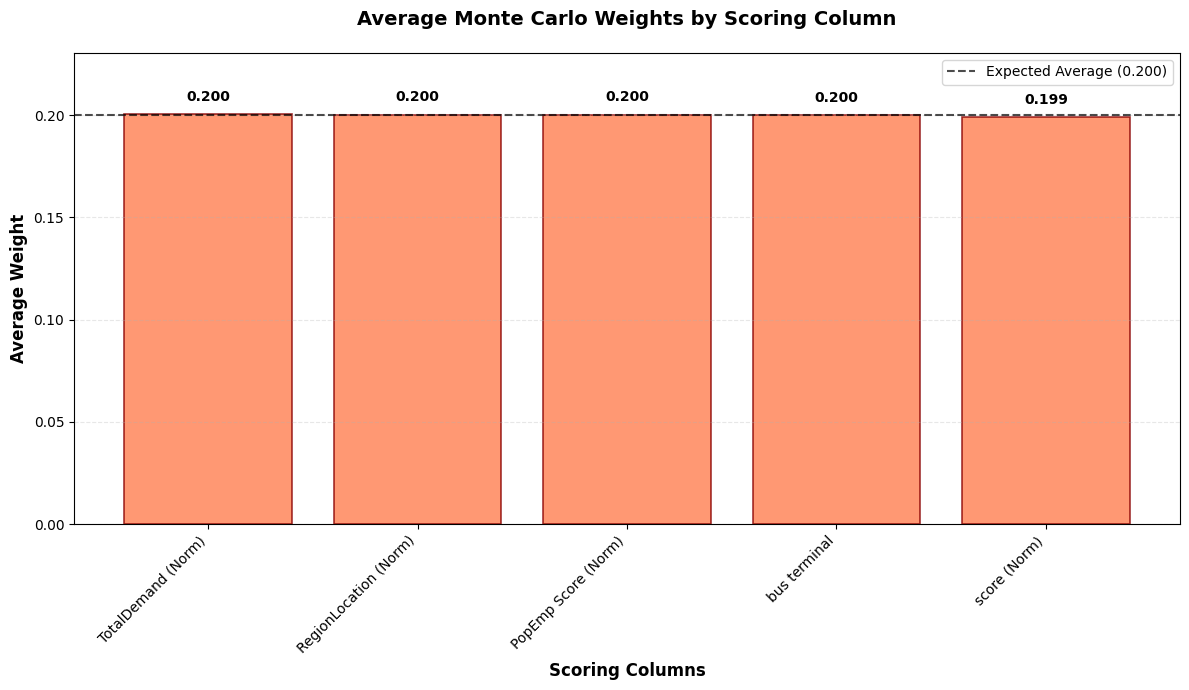

Plot exported as weight_medians.png


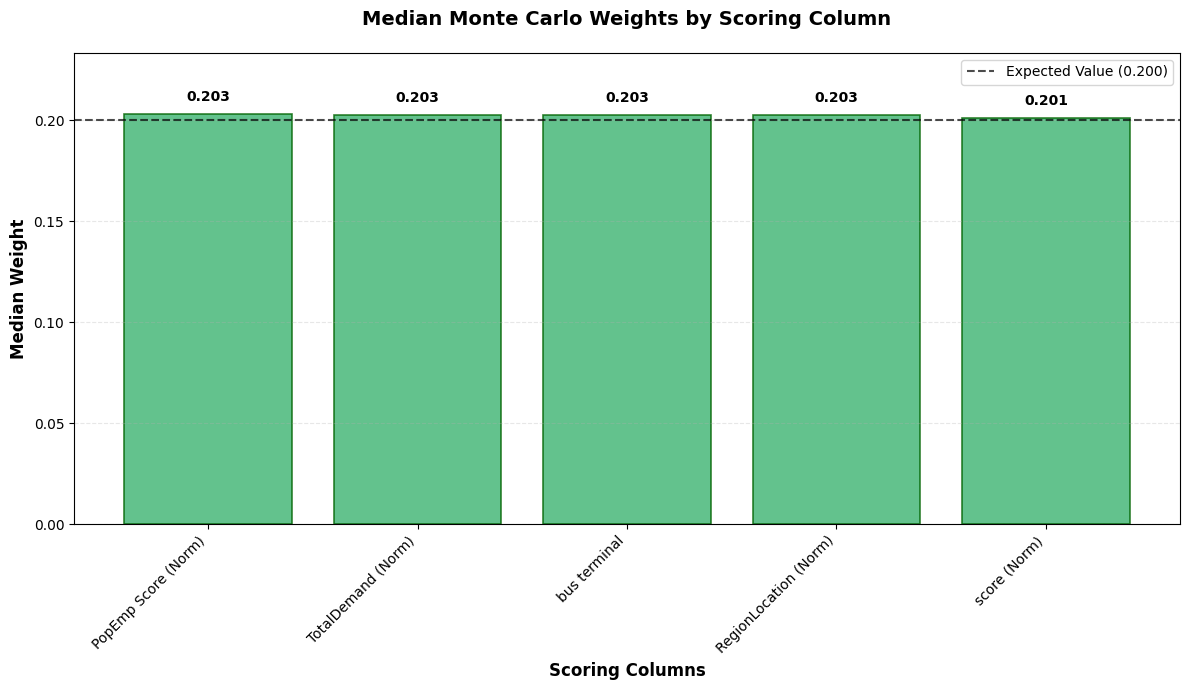

Plot exported as weight_statistics.png


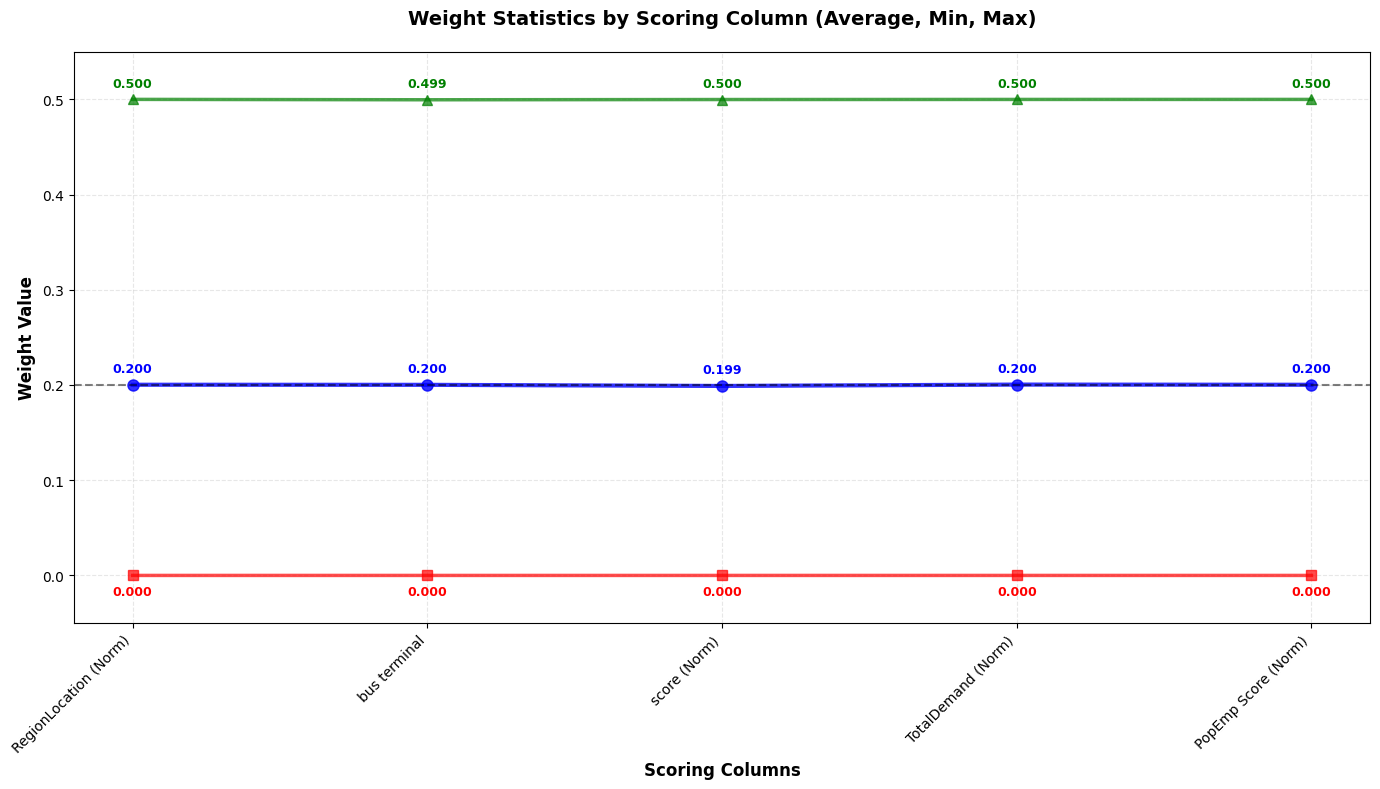

Plot exported as score_distribution.png


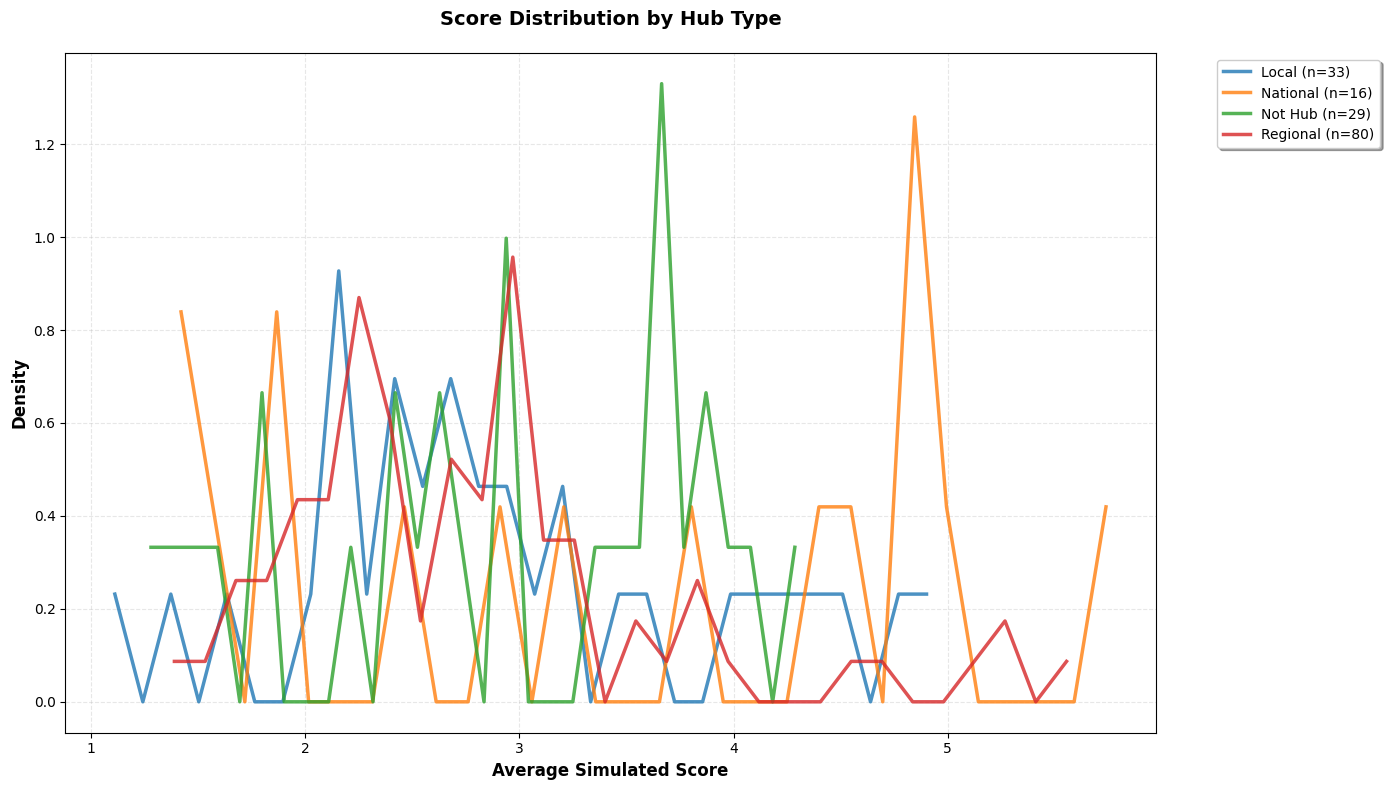


Average Weights of Scoring Columns:
TotalDemand_Norm       0.200409
RegionLocation_Norm    0.200258
PopEmp_Score_Norm      0.200223
bus_terminal           0.200148
score_Norm             0.198963
dtype: float64

Median Weights of Scoring Columns:
PopEmp_Score_Norm      0.202999
TotalDemand_Norm       0.202733
bus_terminal           0.202729
RegionLocation_Norm    0.202680
score_Norm             0.200900
dtype: float64

Weight Statistics Summary:
                Column   Average   Minimum   Maximum     Range
0  RegionLocation_Norm  0.200258  0.000004  0.499890  0.499886
1         bus_terminal  0.200148  0.000003  0.499485  0.499483
2           score_Norm  0.198963  0.000003  0.499736  0.499733
3     TotalDemand_Norm  0.200409  0.000004  0.499832  0.499828
4    PopEmp_Score_Norm  0.200223  0.000005  0.499851  0.499846

Score Distribution Statistics by Hub Type:

Local:
  count: 33
  mean: 2.9174
  median: 2.7408
  std: 0.9664
  min: 1.0445
  max: 4.9667

National:
  count: 16
  mean: 3.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def monte_carlo_scoring(df, num_simulations=10000):
    """
    Performs Monte Carlo simulation to score each HubType based on random weights.

    Args:
        df: DataFrame containing the hub data with normalized columns.
        num_simulations: Number of Monte Carlo simulations to run.

    Returns:
        A tuple containing:
        - DataFrame with the original data and a new column for the average simulated score
        - Dictionary with average weights for each scoring column
        - Dictionary with median weights for each scoring column
        - Dictionary with min weights for each scoring column
        - Dictionary with max weights for each scoring column
    """
    scoring_cols = ['RegionLocation_Norm', 'bus_terminal', 'score_Norm', 'TotalDemand_Norm', 'PopEmp_Score_Norm']
    results = []

    # Track weights across all simulations for statistics
    all_weights = []

    for hub_type in df['HubType'].unique():
        hub_df = df[df['HubType'] == hub_type].copy()
        # Initialize a column to store the sum of scores for each row
        hub_df['Sum_Simulated_Scores'] = 0.0

        for i in range(num_simulations):
            # Generate random weights that sum to 1 and no weight is greater than 0.5
            weights = np.random.rand(len(scoring_cols))
            weights /= weights.sum()  # Normalize first
            while any(weights > 0.5):  # Then check constraint after normalization
                weights = np.random.rand(len(scoring_cols))
                weights /= weights.sum()

            # Store weights for statistics calculation
            all_weights.append(weights.copy())

            # Calculate the weighted score for each row and add it to the sum
            hub_df['Sum_Simulated_Scores'] += (hub_df[scoring_cols] * weights).sum(axis=1)

        # Calculate the average score by dividing the sum by the number of simulations
        hub_df['Average_Simulated_Score'] = hub_df['Sum_Simulated_Scores'] / num_simulations

        # Drop the intermediate sum column
        hub_df.drop(columns='Sum_Simulated_Scores', inplace=True)

        results.append(hub_df)

    # Convert to numpy array for easier calculations
    all_weights = np.array(all_weights)

    # Calculate statistics for weights
    average_weights = np.mean(all_weights, axis=0)
    median_weights = np.median(all_weights, axis=0)
    min_weights = np.min(all_weights, axis=0)
    max_weights = np.max(all_weights, axis=0)

    avg_weight_dict = dict(zip(scoring_cols, average_weights))
    median_weight_dict = dict(zip(scoring_cols, median_weights))
    min_weight_dict = dict(zip(scoring_cols, min_weights))
    max_weight_dict = dict(zip(scoring_cols, max_weights))

    return pd.concat(results), avg_weight_dict, median_weight_dict, min_weight_dict, max_weight_dict

def export_weight_statistics_plot(avg_dict, min_dict, max_dict, filename='weight_statistics.png', figsize=(14, 8)):
    """
    Creates and exports a line plot showing average, min, and max weights for each scoring column.

    Args:
        avg_dict: Dictionary containing average weights for each column
        min_dict: Dictionary containing minimum weights for each column
        max_dict: Dictionary containing maximum weights for each column
        filename: Name of the PNG file to export
        figsize: Tuple for figure size (width, height)
    """
    # Convert to pandas Series (maintain original order)
    scoring_cols = list(avg_dict.keys())
    avg_series = pd.Series([avg_dict[col] for col in scoring_cols], index=scoring_cols)
    min_series = pd.Series([min_dict[col] for col in scoring_cols], index=scoring_cols)
    max_series = pd.Series([max_dict[col] for col in scoring_cols], index=scoring_cols)

    # Create the line plot
    plt.figure(figsize=figsize)
    x_pos = range(len(scoring_cols))

    # Plot lines for average, min, and max
    plt.plot(x_pos, avg_series.values, 'o-', color='blue', linewidth=3,
             markersize=8, label='Average Weight', alpha=0.8)
    plt.plot(x_pos, min_series.values, 's-', color='red', linewidth=2.5,
             markersize=7, label='Minimum Weight', alpha=0.7)
    plt.plot(x_pos, max_series.values, '^-', color='green', linewidth=2.5,
             markersize=7, label='Maximum Weight', alpha=0.7)

    # Customize the plot
    plt.xlabel('Scoring Columns', fontsize=12, fontweight='bold')
    plt.ylabel('Weight Value', fontsize=12, fontweight='bold')
    plt.title('Weight Statistics by Scoring Column (Average, Min, Max)', fontsize=14, fontweight='bold', pad=20)

    # Set x-axis labels with better formatting
    column_labels = [col.replace('_', ' ').replace('Norm', '(Norm)') for col in scoring_cols]
    plt.xticks(x_pos, column_labels, rotation=45, ha='right')

    # Add value labels on points
    for i, (avg_val, min_val, max_val) in enumerate(zip(avg_series.values, min_series.values, max_series.values)):
        plt.text(i, avg_val + 0.01, f'{avg_val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9, color='blue')
        plt.text(i, min_val - 0.01, f'{min_val:.3f}', ha='center', va='top',
                fontweight='bold', fontsize=9, color='red')
        plt.text(i, max_val + 0.01, f'{max_val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9, color='green')

    # Add horizontal line at expected average (0.2 for 5 columns)
    expected_avg = 1.0 / len(scoring_cols)
    plt.axhline(y=expected_avg, color='black', linestyle='--', alpha=0.5,
                label=f'Expected Average ({expected_avg:.3f})')

    # Add legend
    # plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

    # Add grid for better readability
    plt.grid(True, alpha=0.3, linestyle='--')

    # Set y-axis limits to show the full range nicely
    all_values = list(avg_series.values) + list(min_series.values) + list(max_series.values)
    y_margin = (max(all_values) - min(all_values)) * 0.1
    plt.ylim(min(all_values) - y_margin, max(all_values) + y_margin)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Export as PNG
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Plot exported as {filename}")

    # Show the plot
    plt.show()

    # Return summary dataframe
    summary_df = pd.DataFrame({
        'Column': scoring_cols,
        'Average': avg_series.values,
        'Minimum': min_series.values,
        'Maximum': max_series.values,
        'Range': max_series.values - min_series.values
    })

    return summary_df
def export_score_distribution_plot(scored_df, filename='score_distribution.png', figsize=(14, 8)):
    """
    Creates and exports a line plot showing score distribution for each HubType.

    Args:
        scored_df: DataFrame with Monte Carlo scoring results
        filename: Name of the PNG file to export
        figsize: Tuple for figure size (width, height)
    """
    plt.figure(figsize=figsize)

    # Define colors for different HubTypes
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    # Get unique HubTypes
    hub_types = sorted(scored_df['HubType'].unique())

    for i, hub_type in enumerate(hub_types):
        hub_data = scored_df[scored_df['HubType'] == hub_type]['Average_Simulated_Score']

        # Calculate histogram (density) for line plot
        counts, bin_edges = np.histogram(hub_data, bins=30, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Plot line for this HubType
        plt.plot(bin_centers, counts,
                color=colors[i % len(colors)],
                linewidth=2.5,
                label=f'{hub_type} (n={len(hub_data)})',
                alpha=0.8)

    # Customize the plot
    plt.xlabel('Average Simulated Score', fontsize=12, fontweight='bold')
    plt.ylabel('Density', fontsize=12, fontweight='bold')
    plt.title('Score Distribution by Hub Type', fontsize=14, fontweight='bold', pad=20)

    # Add legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)

    # Add grid for better readability
    plt.grid(True, alpha=0.3, linestyle='--')

    # Adjust layout to prevent legend cutoff
    plt.tight_layout()

    # Export as PNG
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Plot exported as {filename}")

    # Show the plot
    plt.show()

    # Return summary statistics for each HubType
    summary_stats = {}
    for hub_type in hub_types:
        hub_data = scored_df[scored_df['HubType'] == hub_type]['Average_Simulated_Score']
        summary_stats[hub_type] = {
            'count': len(hub_data),
            'mean': hub_data.mean(),
            'median': hub_data.median(),
            'std': hub_data.std(),
            'min': hub_data.min(),
            'max': hub_data.max()
        }

    return summary_stats
def export_weight_median_plot(median_dict, filename='weight_medians.png', figsize=(12, 7)):
    """
    Creates and exports a bar plot of median weights for each scoring column.

    Args:
        median_dict: Dictionary containing median weights for each column
        filename: Name of the PNG file to export
        figsize: Tuple for figure size (width, height)
    """
    # Convert to pandas Series and sort
    median_series = pd.Series(median_dict).sort_values(ascending=False)

    # Create the bar plot
    plt.figure(figsize=figsize)
    bars = plt.bar(range(len(median_series)), median_series.values,
                   color='mediumseagreen', alpha=0.8, edgecolor='darkgreen', linewidth=1.2)

    # Customize the plot
    plt.xlabel('Scoring Columns', fontsize=12, fontweight='bold')
    plt.ylabel('Median Weight', fontsize=12, fontweight='bold')
    plt.title('Median Monte Carlo Weights by Scoring Column', fontsize=14, fontweight='bold', pad=20)

    # Set x-axis labels with better formatting
    column_labels = [col.replace('_', ' ').replace('Norm', '(Norm)') for col in median_series.index]
    plt.xticks(range(len(median_series)), column_labels, rotation=45, ha='right')

    # Add value labels on top of bars
    for i, (bar, value) in enumerate(zip(bars, median_series.values)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Add horizontal line at expected median (approximately 0.2 for 5 columns)
    expected_median = 1.0 / len(median_series)
    plt.axhline(y=expected_median, color='black', linestyle='--', alpha=0.7,
                label=f'Expected Value ({expected_median:.3f})')
    plt.legend()

    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Set y-axis limits to show the full range nicely
    plt.ylim(0, max(median_series.values) * 1.15)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Export as PNG
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Plot exported as {filename}")

    # Show the plot
    plt.show()

    return median_series
def export_weight_averages_plot(weight_dict, filename='weight_averages.png', figsize=(12, 7)):
    """
    Creates and exports a bar plot of average weights for each scoring column.

    Args:
        weight_dict: Dictionary containing average weights for each column
        filename: Name of the PNG file to export
        figsize: Tuple for figure size (width, height)
    """
    # Convert to pandas Series and sort
    weight_series = pd.Series(weight_dict).sort_values(ascending=False)

    # Create the bar plot
    plt.figure(figsize=figsize)
    bars = plt.bar(range(len(weight_series)), weight_series.values,
                   color='coral', alpha=0.8, edgecolor='darkred', linewidth=1.2)

    # Customize the plot
    plt.xlabel('Scoring Columns', fontsize=12, fontweight='bold')
    plt.ylabel('Average Weight', fontsize=12, fontweight='bold')
    plt.title('Average Monte Carlo Weights by Scoring Column', fontsize=14, fontweight='bold', pad=20)

    # Set x-axis labels with better formatting
    column_labels = [col.replace('_', ' ').replace('Norm', '(Norm)') for col in weight_series.index]
    plt.xticks(range(len(weight_series)), column_labels, rotation=45, ha='right')

    # Add value labels on top of bars
    for i, (bar, value) in enumerate(zip(bars, weight_series.values)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Add horizontal line at expected average (0.2 for 5 columns)
    expected_avg = 1.0 / len(weight_series)
    plt.axhline(y=expected_avg, color='black', linestyle='--', alpha=0.7,
                label=f'Expected Average ({expected_avg:.3f})')
    plt.legend()

    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Set y-axis limits to show the full range nicely
    plt.ylim(0, max(weight_series.values) * 1.15)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Export as PNG
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Plot exported as {filename}")

    # Show the plot
    plt.show()

    return weight_series

# Apply the Monte Carlo scoring function to the DataFrame
scored_mc, average_weights, median_weights, min_weights, max_weights = monte_carlo_scoring(scored.copy())

# Display the first few rows of the result
display(scored_mc.head())

# Export the bar plot showing average weights of each scoring column
weight_averages = export_weight_averages_plot(average_weights, 'weight_averages.png')

# Export the bar plot showing median weights of each scoring column
weight_medians = export_weight_median_plot(median_weights, 'weight_medians.png')

# Export the weight statistics line plot (average, min, max)
weight_stats_summary = export_weight_statistics_plot(average_weights, min_weights, max_weights, 'weight_statistics.png')

# Export the score distribution plot for each HubType
score_distribution_stats = export_score_distribution_plot(scored_mc, 'score_distribution.png')

# Print the statistics for reference
print("\nAverage Weights of Scoring Columns:")
print(weight_averages)
print("\nMedian Weights of Scoring Columns:")
print(weight_medians)
print("\nWeight Statistics Summary:")
print(weight_stats_summary)
print("\nScore Distribution Statistics by Hub Type:")
for hub_type, stats in score_distribution_stats.items():
    print(f"\n{hub_type}:")
    for stat_name, value in stats.items():
        if stat_name == 'count':
            print(f"  {stat_name}: {value}")
        else:
            print(f"  {stat_name}: {value:.4f}")

In [ ]:
scored_mc.to_csv('/content/drive/MyDrive/Hubs/Scored/Scored_Normalized_Weights_05112025.csv')

In [ ]:
display(scored_mc['Average_Simulated_Score'].describe())

,Average_Simulated_Score
count,158.000000
mean,2.906521
std,0.986545
min,1.044513
25%,2.254897
50%,2.761937
75%,3.515358
max,5.814141


In [ ]:
scored_mc['Rank_within_HubType'] = scored_mc.groupby('HubType')['Average_Simulated_Score'].rank(method='dense', ascending=False)

display(scored_mc.head())

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
8,"POLYGON ((35.29482835672485 32.92382726524076,...","['8a2da4c3119ffff', '8a2da4c3119ffff']","[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_6_1', 'rail_6_2,', 'rail_5_1', 'rail_5_...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,0.840845,0,Regional,4.0,2.309652,1.0,1.271631,1.396290,1.794067,45.0
16,"POLYGON ((35.09908985427145 33.00363199489554,...","['8a2da4cb27a7fff', '8a2da4cb27a7fff']","[31624, 31624]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_3_1', 'rail_3_2,', 'rail_2_1', 'rail_2_2']","גדוד 21, קרית בן-גוריון, נהריה, נפת עכו, מחוז ...",חיפה,טבעת,24623.819497,...,2.606385,2,Regional,7.0,1.824596,7.0,1.683064,2.293270,2.955635,12.0
64,"POLYGON ((35.17458511135136 32.91006322659558,...","['8a2da4d9d08ffff', '8a2da4d9d09ffff', '8a2da4...","[34071, 31525, 31525]","[LRT, Rail, Interurban Rail, Suburban Rail]",Haifa,"['lrt06,', 'rail_6_1', 'rail_6_2,', 'rail_5_1'...","85, מועצה אזורית משגב, נפת עכו, מחוז הצפון, ישראל",חיפה,טבעת,6941.057897,...,0.100203,2,Regional,7.0,2.697697,7.0,1.157098,1.020008,2.773029,17.0
125,POLYGON ((34.79780044590015 31.368587719478775...,"['8a3f4c0634b7fff', '8a3f4c0634b7fff']","[463793, 467925]","[Rail, LRT, Interurban Rail]",National,"['rail_3_1', 'rail_3_2', 'rail_4_1', 'rail_4_2...","להבים רהט, שדרות תמר, להבים, נפת באר שבע, מחוז...",באר שבע,טבעת,37918.210043,...,0.641593,2,Regional,7.0,2.794708,7.0,2.078500,1.295061,3.032044,11.0
184,"POLYGON ((34.60391074419518 31.67550851116559,...","['8a3f4c205757fff', '8a3f4c205757fff']","[400841, 400841]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_11_1', 'rail_11_2', 'rail_12_1', 'rail_...","אשקלון, הרכבת, אזור התעשיה הצפוני, אשקלון, נפת...",דרום,דרום,7449.073821,...,1.727843,0,Regional,4.0,2.794708,1.0,1.172209,1.846928,1.961148,39.0


In [ ]:
for hub_type in scored_mc['HubType'].unique():
  print(f"Top 5 Hubs for {hub_type}:")
  display(scored_mc[scored_mc['HubType'] == hub_type].sort_values('Rank_within_HubType').head())

Top 5 Hubs for Regional:


,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
405,MULTIPOLYGON (((35.00633147044629 32.807199073...,"['8a3f4d84b027fff', '8a3f4d84b10ffff', '8a3f4d...","[1021, 31616, 31616, 1020, 34082]","[BRT, Rail, Rail, LRT, Interurban Rail, S...",Haifa,"['lrt03', 'lrt04', 'lrt07', 'lrt08,', 'rail_6_...","קיבוץ גלויות, עיר תחתית מזרח, רובע העיר התחתית...",חיפה,גלעין,4524.377569,...,4.278071,0,Regional,10.0,10.000000,1.0,1.085215,3.142567,4.846091,1.0
507,MULTIPOLYGON (((34.98121164532547 32.829469820...,"['8a3f4dba5327fff', '8a3f4dba5327fff', '8a3f4d...","[31605, 31605, 1024, 34085]","[Rail, Rail, BRT, LRT, Interurban Rail, S...",National,"['R321-1', 'R330-2', 'R325-2', 'R325-1', 'R330...","ההגנה, קריית אליעזר, רובע מערב חיפה, חיפה, נפת...",חיפה,גלעין,32877.762964,...,2.781415,2,Regional,10.0,7.592357,7.0,1.928574,2.382193,4.780780,2.0
346,POLYGON ((35.22436421287473 31.766386252196963...,"['8a3f4cb61a57fff', '8a3f4cb61a77fff']","[50111, 51152]","[Rail, LRT, Suburban Rail]",National,"['rail_18_1', 'rail_18_2', 'rail_14_1', 'rail_...","עמק רפאים, המושבה הגרמנית, ירושלים, נפת ירושלי...",ירושלים,גלעין,126952.867877,...,3.179036,2,Regional,10.0,2.891720,7.0,4.726795,2.584204,4.436676,3.0
497,POLYGON ((35.06926603182285 32.832523654306534...,"['8a3f4db3681ffff', '8a3f4db3681ffff', '8a3f4d...","[31611, 31611, 31611, 31611]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_2_1', 'rail_2_2,', 'rail_3_1', 'rail_3_...","קרית מוצקין, ששת הימים, קרית חיים, רובע קריית ...",חיפה,גלעין,35273.327560,...,2.782373,0,Regional,10.0,7.354238,1.0,1.999829,2.382680,4.346499,4.0
649,MULTIPOLYGON (((34.78470676497412 32.065730256...,"['8a3f4dc1e91ffff', '8a3f4dc1e987fff', '8a3f4d...","[522005, 511015, 512020]","[Metro, LRT]",Tel,"['Red-N', 'Red-S', 'Red2-N', 'Red2-S', 'Shut-N...","יצחק (זיקו) גרציאני, גני שרונה, תל־אביב–יפו, נ...",תל אביב,גלעין,218051.810000,...,17.775676,0,Regional,1.0,3.182754,1.0,7.436492,10.000000,4.316762,5.0


Top 5 Hubs for Local:


,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
513,"POLYGON ((34.82366502043951 32.09021073181436,...","['8a3f4dc00687fff', '8a3f4dc006b7fff']","[525244, 511009]","[BRT, LRT]",Tel,"['Red-N', 'Red-S', 'Red2-N', 'Red2-S', 'Shut-N...","3, בר כוכבא, תל גיבורים, בני ברק, נפת תל אביב,...",תל אביב,טבעת,85633.970000,...,9.852327,0,Local,1.0,2.762887,1.0,10.000000,10.000000,4.746823,1.0
419,"POLYGON ((35.05652586433928 32.80415839022309,...","['8a3f4d86b617fff', '8a3f4d86b617fff', '8a3f4d...","[1016, 1016, 34005, 34005]","[BRT, LRT]",Haifa,"['lrt01', 'lrt02', 'lrt03', 'lrt04', 'lrt07', ...","22, רובע מפרץ חיפה, חיפה, נפת חיפה, מחוז חיפה,...",חיפה,טבעת,24476.539001,...,0.339902,0,Local,7.0,10.000000,1.0,3.354440,1.000000,4.272160,2.0
58,MULTIPOLYGON (((35.08953129526264 32.858452695...,"['8a2da4d92c87fff', '8a3f4db34b2ffff']","[34051, 1006]","[LRT, BRT]",Haifa,"['R321-1', 'R1001-2', 'R322-1', 'R1002-2', 'R3...","שדרות ירושלים, משכנות האמנים, קריית מוצקין, נפ...",חיפה,טבעת,15316.333161,...,2.359003,3,Local,7.0,3.690722,10.0,2.359063,2.910334,3.786750,3.0
406,MULTIPOLYGON (((34.99796768774247 32.819532843...,"['8a3f4d84b21ffff', '8a3f4d84b257fff']","[1022, 34084]","[BRT, LRT]",Haifa,"['lrt03', 'lrt04', 'lrt07', 'lrt08,', 'R327-1'...","59, העצמאות, עיר תחתית, רובע העיר התחתית, חיפה...",חיפה,גלעין,3881.218791,...,2.848631,0,Local,10.0,4.247423,1.0,1.116487,3.373586,3.735086,4.0
784,MULTIPOLYGON (((34.78967840562825 31.965098189...,"['8a3f4dca4227fff', '8a3f4dca431ffff', '8a3f4d...","[516022, 515022, 511273, 150274, 150620, 51504...","[LRT, BRT]",Tel,"['BRT1-2,', 'BRT1-1', 'BRT1-2,', 'LRT-L1', 'LR...","קרביץ שער העיר, 6, ההסתדרות, קרית גנים, ראשון ...",תל אביב,טבעת,29820.375300,...,4.241880,3,Local,1.0,5.639175,10.0,3.935118,4.691783,3.658841,5.0


Top 5 Hubs for National:


,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
625,MULTIPOLYGON (((34.79768431607108 32.081936375...,"['8a3f4dc1c1a7fff', '8a3f4dc1cc5ffff', '8a3f4d...","[521024, 513001, 400080, 400080, 400080, 40008...","[Metro, LRT, Rail, Rail, HighSpeed Rail, ...",Tel,"['Mgt1-E', 'Mgt2-E,', 'Me1-1N', 'Me1-1S', 'Me1...","500, דרך נמיר, צמרות איילון, תל־אביב–יפו, נפת ...",תל אביב,גלעין,333765.020000,...,13.689421,3,National,1.0,10.000000,10.0,4.327228,8.090662,5.290811,1.0
583,MULTIPOLYGON (((34.79524820409781 32.071884771...,"['8a3f4dc11247fff', '8a3f4dc11247fff', '8a3f4d...","[400090, 400090, 522006, 521023, 511013]","[Rail, Rail, Metro, LRT, Interurban Rail, ...",National,"['Me1-1N', 'Me1-1S', 'Me1-2N', 'Me1-2S,', 'Red...","Tel Aviv City Center, 136, איילון דרום, מונטיפ...",תל אביב,גלעין,805578.870000,...,17.224479,0,National,1.0,3.556433,1.0,10.000000,10.000000,4.917054,2.0
360,MULTIPOLYGON (((35.19976940775025 31.784089572...,"['8a3f4cb68c07fff', '8a3f4cb68d1ffff', '8a3f4c...","[51023, 51103, 51182, 51022, 50202, 50202, 50202]","[LRT, Rail, Rail, HighSpeed Rail, Interurb...",Jerusalem,"['rail_21_1', 'rail_21_2,', 'LRT31', 'LRT32', ...","הרצל, קרית משה, ירושלים, נפת ירושלים, מחוז ירו...",ירושלים,גלעין,282761.989019,...,10.723344,0,National,10.0,2.147856,1.0,3.714002,6.488640,4.471292,3.0
403,MULTIPOLYGON (((35.037460581004886 32.79108697...,"['8a3f4d848987fff', '8a3f4d848997fff', '8a3f4d...","[34000, 31508, 32001, 31609, 31609, 1017]","[LRT, Rail, Cable, Line, Rail, Rail, BRT...",Haifa,"['c001,', 'rail_2_1', 'rail_2_2', 'rail_9_1', ...","דרך העמקים, צ׳ק פוסט, רובע מפרץ חיפה, חיפה, נפ...",חיפה,גלעין,215309.843367,...,1.736560,3,National,10.0,3.806998,10.0,2.903003,1.634744,4.262901,4.0
373,MULTIPOLYGON (((35.217549907360535 31.78234282...,"['8a3f4cb6c01ffff', '8a3f4cb6c037fff', '8a3f4c...","[51019, 50011, 50011, 50011, 51106, 51018]","[LRT, Rail, Rail, HighSpeed Rail, Interurb...",Jerusalem,"['LRT71', 'LRT72', 'LRT61', 'LRT62,', 'rail_21...","ככר הדוידקא, זכרון משה, ירושלים, נפת ירושלים, ...",ירושלים,גלעין,247480.875311,...,10.183793,0,National,10.0,1.795711,1.0,3.289806,6.197220,4.257708,5.0


Top 5 Hubs for Not Hub:


,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
435,"POLYGON ((34.9049898031595 32.32269679581671, ...","['8a3f4d89662ffff', '8a3f4d89662ffff']","[511163, 511163]","[BRT, LRT]",Netanya,"['LRT141,', 'LRT-L1']","57, בית יצחק - שער חפר, מועצה אזורית עמק חפר, ...",תל אביב,טבעת,37029.660000,...,0.928893,3,Not Hub,1.0,2.8,10.0,10.000000,3.002722,3.966502,1.0
746,MULTIPOLYGON (((34.85715807340049 32.272142147...,"['8a3f4dc62077fff', '8a3f4dc62077fff', '8a3f4d...","[511228, 511228, 511227, 511227, 511224, 51122...","[BRT, LRT]",Netanya,"['LRT141,', 'LRT142']","שדרות גיבורי ישראל, אזור התעשיה פולג, קריית נו...",תל אביב,טבעת,10874.870205,...,1.767160,0,Not Hub,1.0,10.0,1.0,3.420475,5.344970,3.955626,2.0
404,POLYGON ((35.029150184378096 32.79047389379246...,['8a3f4d848c0ffff'],[32002],"[Cable, Line]",Haifa,"['c001', 'c002']","23, צ׳ק פוסט, רובע מפרץ חיפה, חיפה, נפת חיפה, ...",חיפה,גלעין,4835.454093,...,1.899376,0,Not Hub,10.0,1.0,1.0,1.901193,5.714403,3.725706,3.0
416,"POLYGON ((35.03067152268523 32.78185679536056,...","['8a3f4d84eaeffff', '8a3f4d84eaeffff']","[32003, 32003]","[Cable, Line]",Haifa,"['c001', 'c002']","פז, דרך בר יהודה, א.ת. תל חנן, תל חנן, רובע נו...",חיפה,טבעת,1358.485545,...,2.166761,3,Not Hub,7.0,1.0,10.0,1.026523,6.461518,3.699857,4.0
415,POLYGON ((35.020687802250094 32.77246075615788...,['8a3f4d84e62ffff'],[32005],"[Cable, Line]",Haifa,"['c001', 'c002']","הטכניון - מכון טכנולוגי לישראל, קו 300, קרית ה...",חיפה,גלעין,1367.144325,...,2.022330,0,Not Hub,10.0,1.0,1.0,1.028702,6.057955,3.619785,5.0


In [ ]:
scored_mc.to_csv('/content/drive/MyDrive/Hubs/Scored/Scored_By_MonteCarlo_29-10-2025.csv', encoding='utf-8')

In [ ]:
scored_mc.head(1)

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
8,"POLYGON ((35.29482835672485 32.92382726524076,...","['8a2da4c3119ffff', '8a2da4c3119ffff']","[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_6_1', 'rail_6_2,', 'rail_5_1', 'rail_5_...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,0.840845,0,Regional,4.0,2.309652,1.0,1.271631,1.39629,1.794067,45.0


In [ ]:
scored_mc['h3_index'] = scored_mc['h3_index'].apply(lambda x: make_list(x))

In [ ]:
scored_mc[scored_mc.index==736]

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
736,"POLYGON ((34.86901235353748 32.31796826525945,...",8a3f4dc610cffff,"[400020, 400020]","[Interurban Rail, Suburban Rail]",national,"['rail_3_1', 'rail_3_2', 'rail_4_1', 'rail_4_2...","הרכבת, רמת אפרים, נתניה, נפת השרון, מחוז המרכז...",תל אביב,טבעת,19126.69,...,1.164239,1,Regional,1.0,4.602487,4.0,1.511101,2.221026,2.066061,35.0
736,"POLYGON ((34.86901235353748 32.31796826525945,...",8a3f4dc610cffff,"[400020, 400020]","[Interurban Rail, Suburban Rail]",national,"['rail_3_1', 'rail_3_2', 'rail_4_1', 'rail_4_2...","הרכבת, רמת אפרים, נתניה, נפת השרון, מחוז המרכז...",תל אביב,טבעת,19126.69,...,1.164239,1,Regional,1.0,4.602487,4.0,1.511101,2.221026,2.066061,35.0


In [ ]:
scored_mc = scored_mc.explode('h3_index')

In [ ]:
scored_mc

,geometry,h3_index,node,Mode_Planned,Model,Line_Unique,address,area,location,TotalDemand,...,score,bus_terminal,HubType,RegionLocation_Norm,score_Norm,bus_terminal_Norm,TotalDemand_Norm,PopEmp_Score_Norm,Average_Simulated_Score,Rank_within_HubType
group,,,,,,,,,,,,,,,,,,,,,
8,"POLYGON ((35.29482835672485 32.92382726524076,...",8a2da4c3119ffff,"[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_6_1', 'rail_6_2,', 'rail_5_1', 'rail_5_...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,0.840845,0,Regional,4.0,2.309652,1.0,1.271631,1.396290,1.794067,45.0
8,"POLYGON ((35.29482835672485 32.92382726524076,...",8a2da4c3119ffff,"[31656, 31656]","[Rail, Interurban Rail, Suburban Rail]",National,"['rail_6_1', 'rail_6_2,', 'rail_5_1', 'rail_5_...","דרור, המערבית, כרמיאל, נפת עכו, מחוז הצפון, 21...",צפון,צפון,10791.605236,...,0.840845,0,Regional,4.0,2.309652,1.0,1.271631,1.396290,1.794067,45.0
16,"POLYGON ((35.09908985427145 33.00363199489554,...",8a2da4cb27a7fff,"[31624, 31624]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_3_1', 'rail_3_2,', 'rail_2_1', 'rail_2_2']","גדוד 21, קרית בן-גוריון, נהריה, נפת עכו, מחוז ...",חיפה,טבעת,24623.819497,...,2.606385,2,Regional,7.0,1.824596,7.0,1.683064,2.293270,2.955635,12.0
16,"POLYGON ((35.09908985427145 33.00363199489554,...",8a2da4cb27a7fff,"[31624, 31624]","[Rail, HighSpeed Rail, Interurban Rail]",National,"['rail_3_1', 'rail_3_2,', 'rail_2_1', 'rail_2_2']","גדוד 21, קרית בן-גוריון, נהריה, נפת עכו, מחוז ...",חיפה,טבעת,24623.819497,...,2.606385,2,Regional,7.0,1.824596,7.0,1.683064,2.293270,2.955635,12.0
64,"POLYGON ((35.17458511135136 32.91006322659558,...",8a2da4d9d08ffff,"[34071, 31525, 31525]","[LRT, Rail, Interurban Rail, Suburban Rail]",Haifa,"['lrt06,', 'rail_6_1', 'rail_6_2,', 'rail_5_1'...","85, מועצה אזורית משגב, נפת עכו, מחוז הצפון, ישראל",חיפה,טבעת,6941.057897,...,0.100203,2,Regional,7.0,2.697697,7.0,1.157098,1.020008,2.773029,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,POLYGON ((35.003244201305776 32.27066920609295...,8a3f4dd68c4ffff,"[511144, 511144]","[BRT, LRT]",Netanya,"['LRT141,', 'LRT142']","444, الطيبة, נפת השרון, מחוז המרכז, ישראל",תל אביב,טבעת,4286.390000,...,2.547216,0,Not Hub,1.0,2.800000,1.0,1.763070,7.524569,2.626329,13.0
894,"POLYGON ((34.98274689505411 32.28196812964349,...",8a3f4dd6bc6ffff,"[511142, 511142]","[BRT, LRT]",Netanya,"['LRT141,', 'LRT142']","قلنسوة, נפת השרון, מחוז המרכז, 4283000, ישראל",תל אביב,טבעת,5042.160000,...,1.018153,0,Not Hub,1.0,2.800000,1.0,1.953192,3.252130,1.804357,23.0
894,"POLYGON ((34.98274689505411 32.28196812964349,...",8a3f4dd6bc6ffff,"[511142, 511142]","[BRT, LRT]",Netanya,"['LRT141,', 'LRT142']","قلنسوة, נפת השרון, מחוז המרכז, 4283000, ישראל",תל אביב,טבעת,5042.160000,...,1.018153,0,Not Hub,1.0,2.800000,1.0,1.953192,3.252130,1.804357,23.0


In [ ]:
scored_mc.to_csv('/content/drive/MyDrive/Hubs/Scored/h3_index_for_hub_naming_28102025.csv', encoding='utf-8')

# upload temp file to explode by h3_index

In [ ]:
old = pd.read_csv('/content/drive/MyDrive/Hubs/Hubs_Grouped_And_Scored.csv', encoding='utf-8')

In [ ]:
old.head(1)

,HubId,HubName,Area,H3_Index,H3_Index.1,TotalDemand,OwnershipScore,RegionLocationScore,ModeLinesScore,Mode,LOG10,DemandScore_1-10,DemandWeight,OwnershipWeight,RegLocWeight,UniquModesWeight
0,101,Merkazit Hakrayot,Haifa,"{'8a2da4d92c87fff', '8a2da4d92ca7fff', '8a2da4...",3,15651.87116,3,3,15,2,4.194566,7.359054,NaN,NaN,NaN,NaN


In [ ]:
def make_list_old(txt):
  txt = txt.replace('{','').replace('}','').replace("'","").replace(' ','').split(',')
  return txt

In [ ]:
old['H3_Index'] = old['H3_Index'].apply(lambda x: make_list_old(x))

In [ ]:
old = old.explode('H3_Index')

In [ ]:
old.to_csv('/content/drive/MyDrive/Hubs/OLD_Hubs_Grouped_And_Scored_exploded.csv', encoding='utf-8')

In [ ]:
\[
\text{Given radii } \{r_i\}_{i=0}^{M} \text{ and } \beta>0,\quad
m_i \coloneqq \frac{r_{i-1}+r_i}{2}\quad (i=1,\dots,M),\quad
d_i \coloneqq m_i^{\beta}.
\]

\[
\text{Let } P_{k i} \text{ and } E_{k i} \text{ denote population and employment for row } k \text{ and ring } i,
\]
\[
C_{k i} \coloneqq w_{\text{pop}}\,P_{k i} + w_{\text{emp}}\,E_{k i}.
\]

\[
\boxed{\,s_k \;=\; \sum_{i=1}^{M} \frac{C_{k i}}{d_i}
\;=\; \sum_{i=1}^{M} \frac{w_{\text{pop}}\,P_{k i} + w_{\text{emp}}\,E_{k i}}{\left(\frac{r_{i-1}+r_i}{2}\right)^{\beta}}\,}
\qquad (k=1,\dots,N).
\]

\[
\textbf{(Matrix form)}\quad
\mathbf{s} \;=\; \bigl(w_{\text{pop}}\mathbf{P} + w_{\text{emp}}\mathbf{E}\bigr)\,\mathbf{D}^{-1}\,\mathbf{1}_M,
\]
where \(\mathbf{P},\mathbf{E}\in\mathbb{R}^{N\times M}\), \(\mathbf{D}=\mathrm{diag}(d_1,\dots,d_M)\), and \(\mathbf{1}_M\) is an \(M\)-vector of ones.


SyntaxError: unexpected character after line continuation character (ipython-input-456247028.py, line 2)

\[
\text{Given radii } \{r_i\}_{i=0}^{M} \text{ and } \beta>0,\quad
m_i \coloneqq \frac{r_{i-1}+r_i}{2}\quad (i=1,\dots,M),\quad
d_i \coloneqq m_i^{\beta}.
\]

\[
\text{Let } P_{k i} \text{ and } E_{k i} \text{ denote population and employment for row } k \text{ and ring } i,
\]
\[
C_{k i} \coloneqq w_{\text{pop}}\,P_{k i} + w_{\text{emp}}\,E_{k i}.
\]

\[
\boxed{\,s_k \;=\; \sum_{i=1}^{M} \frac{C_{k i}}{d_i}
\;=\; \sum_{i=1}^{M} \frac{w_{\text{pop}}\,P_{k i} + w_{\text{emp}}\,E_{k i}}{\left(\frac{r_{i-1}+r_i}{2}\right)^{\beta}}\,}
\qquad (k=1,\dots,N).
\]

\[
\textbf{(Matrix form)}\quad
\mathbf{s} \;=\; \bigl(w_{\text{pop}}\mathbf{P} + w_{\text{emp}}\mathbf{E}\bigr)\,\mathbf{D}^{-1}\,\mathbf{1}_M,
\]
where \(\mathbf{P},\mathbf{E}\in\mathbb{R}^{N\times M}\), \(\mathbf{D}=\mathrm{diag}(d_1,\dots,d_M)\), and \(\mathbf{1}_M\) is an \(M\)-vector of ones.


